In [28]:
import numpy as np
import matplotlib.pyplot as plt
import json

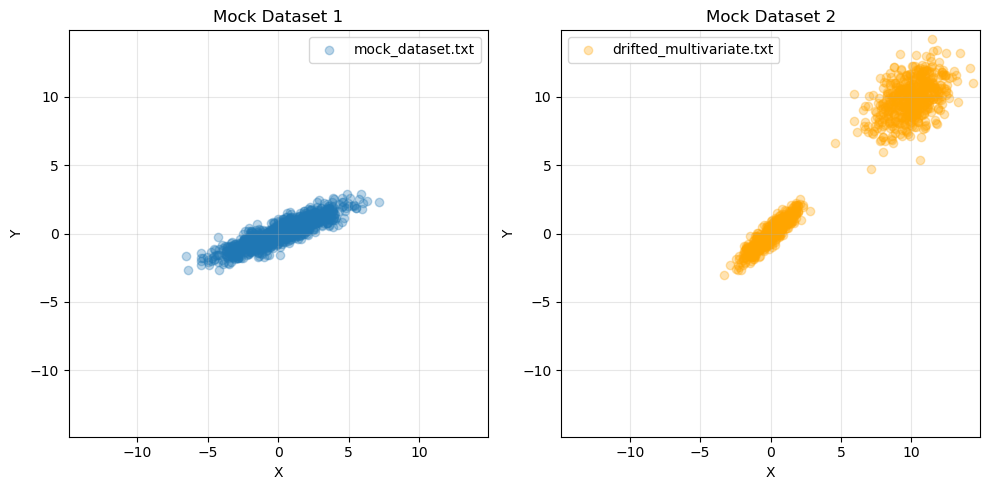

Dataset 1 shape: (1000, 2)
Dataset 2 shape: (1000, 2)


In [40]:


# Load the datasets
dataset1 = np.genfromtxt('testing/mock_dataset.txt', skip_header=True, delimiter=",", dtype=float)
dataset2 = np.genfromtxt('testing/drifted_multivariate.txt', skip_header=True, delimiter=",", dtype=float)

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot dataset 1
ax1.scatter(dataset1[:, 0], dataset1[:, 1], alpha=0.3, label='mock_dataset.txt')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_title('Mock Dataset 1')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot dataset 2
ax2.scatter(dataset2[:, 0], dataset2[:, 1], alpha=0.3, color='orange', label='drifted_multivariate.txt')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Mock Dataset 2')
ax2.grid(True, alpha=0.3)
ax2.legend()

maxi = np.amax([abs(dataset1[:, 0]), abs(dataset1[:, 1]), abs(dataset2[:, 0]), abs(dataset2[:, 1])])+0.5

for ax in (ax1, ax2):
    ax.set(xlim=[-maxi, maxi], ylim=[-maxi, maxi])

plt.tight_layout()
plt.show()

print(f"Dataset 1 shape: {dataset1.shape}")
print(f"Dataset 2 shape: {dataset2.shape}")


In [11]:

trial = {"loc": [[0, 0], [10, 10]], "cov": [[[1, 0.9], [0.9, 1]], [[2, 0.6], [0.6, 2]]], "stdev": [2, 2]} # Output that stdev (entries=1) has a different number of entries than loc and cov (entries=2) 
trial2 = {"loc": [[1, 1]], "cov": [[[1, 0.9], [0.9, 1]], [[2, 0.6], [0.6, 2]]], "stdev": [[2, 2], [1, 1]]} # Output that loc (entries=1) has a different number of entries to cov and stdev (entries=2) 
trial3 = {"loc": [[0, 0], [10, 10]], "cov": [[[1, 0.9], [0.9, 1]], [[2, 0.6], [0.6, 2]]], "stdev": [[2, 2], [1, 1]]} # Valid trial
trial4 = {"loc": [[0, 0], [10, 10], [8, 8]], "cov": [[[1, 0.9], [0.9, 1]], [[2, 0.6], [0.6, 2]]], "stdev": [[2, 2]]} # Output that all three have different numbers of entries (or just output the first error) loc (entries=3), cov (entries=2), stdev (entries=1)


def validate_trial(trial):
    import numpy as np
    counts = {}
    for k, v in trial.items():
        try:
            shape = np.shape(v)
            if shape == ():
                count = 1
            else:
                count = shape[0]
        except Exception:
            try:
                count = len(v)
            except Exception:
                count = 1
        counts[k] = int(count)
    unique = set(counts.values())
    if len(unique) == 1:
        n = unique.pop()
        print(f"Validation successful: All entries have the same number of components: {n}")
        return True
    else:
        print("Validation error: mismatched numbers of entries")
        for k, c in counts.items():
            print(f" - {k}: entries={c}")
        return False

# Run validation on provided examples
for name, t in [('trial', trial), ('trial2', trial2), ('trial3', trial3), ('trial4', trial4)]:
    print('\n' + name + ':')
    validate_trial(t)


trial:
Validation successful: All entries have the same number of components: 2

trial2:
Validation error: mismatched numbers of entries
 - loc: entries=1
 - cov: entries=2
 - stdev: entries=2

trial3:
Validation successful: All entries have the same number of components: 2

trial4:
Validation error: mismatched numbers of entries
 - loc: entries=3
 - cov: entries=2
 - stdev: entries=1


In [21]:
print(np.shape([[[1, 0.9], [0.9, 1]], [[2, 0.6], [0.6, 2]], [[1, 0.9], [0.9, 1]], [[2, 0.6], [0.6, 2]]]))

(4, 2, 2)


In [29]:
json.loads(open('drift_data.json').read())

{'loc': [[0, 0], [10, 10]],
 'cov': [[[1, 0.9], [0.9, 1]], [[2, 0.95], [0.95, 2]]],
 'stdev': [[2, 2], [1, 1]]}

In [86]:
json_file = "testing/drift_data.json"
with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)
    tmp = data.copy()
    for key, value in tmp.items():
        data[key] = np.array(value)


    trial = data["cov"]

    print(trial[:, 0, 1])
    print(trial[:, 1, 0])
    print(np.any(trial[:, 0, 1] != trial[:, 1, 0]))
    

[0.9  0.95]
[0.9  0.95]
False


In [88]:
for key, value in data.items():
    print(key, np.ndim(value), len(value))

trial = set()
trial.add(5)
trial.add(2)
trial.add(5)
print(trial)
print(np.ndim(3))


loc 2 2
cov 3 2
stdev 1 2
{2, 5}
0


In [90]:
from . import testing/create

SyntaxError: invalid syntax (3019203282.py, line 1)

hello
